<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Analysis-ML/blob/main/03_Deep_Learning_Architectures_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook 03: Deep Learning Architectures (MLP, CNN, LSTM)
###Environment Setup and Initialization

This section initializes the deep learning workspace. It mounts Google Drive for artifact retrieval, imports necessary Keras/TensorFlow modules, and establishes fixed random seeds to ensure strict scientific reproducibility across all neural network training sessions. Extraneous TensorFlow C++ logs are suppressed to maintain a clean output console.

In [ ]:
import os
import time
import joblib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Suppress TensorFlow info/warning logs for a cleaner terminal
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

from google.colab import drive

# 2. Enforce strict reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seeds secured at {SEED} for reproducibility.")

# 3. Mount Drive and define exact project paths (Matched with Notebook 02)
drive.mount('/content/drive')
project_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'
model_save_dir = f'{project_dir}/saved_models'

print("\nPhase 1 Complete: Deep Learning Environment Initialized.")
print(f"Project folder : {project_dir}")
print(f"Model save dir : {model_save_dir}")
print(f"TensorFlow Version: {tf.__version__}")

Random seeds secured at 42 for reproducibility.
Mounted at /content/drive

Phase 1 Complete: Deep Learning Environment Initialized.
Project folder : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN
Model save dir : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models
TensorFlow Version: 2.20.0


### Data Retrieval and Tensor Reshaping

This section loads the pre-processed, snoop-free feature matrices exported from the Machine Learning pipeline (Notebook 02). Because Deep Learning architectures like 1D-CNNs and LSTMs expect three-dimensional input tensors (Batch, Timesteps, Channels), the two-dimensional tabular data (Samples, Features) is expanded with a trailing channel dimension using np.expand_dims.

In [ ]:
print("Phase 2: Data Retrieval and Reshaping\n")

try:
    # 1. load the matrices exported from notebook 02
    x_train_raw = np.load(f'{project_dir}/X_train_final.npy')
    x_test_raw  = np.load(f'{project_dir}/X_test_final.npy')

    y_train = np.load(f'{project_dir}/y_train.npy')
    y_test  = np.load(f'{project_dir}/y_test.npy')
    print("Feature arrays and labels successfully loaded.")
except FileNotFoundError as e:
    print(f"Error: Could not find files. Details: {e}")

print("\nOriginal Machine Learning Shapes (2D):")
print(f"x_train_raw : {x_train_raw.shape}")
print(f"x_test_raw  : {x_test_raw.shape}")

# 2. reshape for deep learning
x_train_dl = np.expand_dims(x_train_raw, axis=-1)
x_test_dl  = np.expand_dims(x_test_raw, axis=-1)

print("\nDeep Learning Tensor Shapes (3D):")
print(f"x_train_dl  : {x_train_dl.shape} -> (Samples, Features, Channels)")
print(f"x_test_dl   : {x_test_dl.shape}")
print(f"y_train     : {y_train.shape}")
print(f"y_test      : {y_test.shape}")

Phase 2: Data Retrieval and Reshaping

Feature arrays and labels successfully loaded.

Original Machine Learning Shapes (2D):
x_train_raw : (16305, 100)
x_test_raw  : (4077, 100)

Deep Learning Tensor Shapes (3D):
x_train_dl  : (16305, 100, 1) -> (Samples, Features, Channels)
x_test_dl   : (4077, 100, 1)
y_train     : (16305,)
y_test      : (4077,)


### Multi-Layer Perceptron (MLP) Architecture

The Multi-Layer Perceptron serves as the baseline neural network. Unlike sequential DL models, standard Dense layers require 2D input arrays (Samples, Features). The architecture includes multiple fully connected layers with ReLU activation, interspersed with Dropout layers (0.3) to prevent overfitting on the complex EEG feature space. Early Stopping is implemented to monitor validation loss and dynamically halt training at optimal convergence.

In [ ]:
print("Initializing and Training MLP Model\n")

# initialize global dictionaries to store results for the final DL comparison table
if 'dl_results' not in locals():
    dl_results = []
    trained_dl_models = {}

# 1. build the mlp architecture
# using x_train_raw (2D) because dense layers do not accept 3D sequential tensors
mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train_raw.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name="MLP_Baseline")

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3. train the model
print("Training MLP Model (Early Stopping Enabled)...")
t0 = time.time()
history_mlp = mlp_model.fit(
    x_train_raw,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=2  # verbose=2 keeps the terminal output clean (one line per epoch)
)
t_train_mlp = time.time() - t0

# 4. evaluate on test set
print("\nEvaluating MLP on Test Set...")
t0 = time.time()
y_pred_probs_mlp = mlp_model.predict(x_test_raw, verbose=0)
t_pred_mlp = (time.time() - t0) / len(x_test_raw)

# convert sigmoid probabilities to binary predictions (threshold = 0.5)
y_pred_mlp = (y_pred_probs_mlp > 0.5).astype(int).flatten()

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)

print(f"  Accuracy : {acc_mlp:.4f}")
print(f"  F1-Score : {f1_mlp:.4f}")

# store results for later comparison
dl_results.append({
    'Model': 'MLP',
    'Accuracy': round(acc_mlp, 4),
    'F1-Score': round(f1_mlp, 4),
    'Train Time(s)': round(t_train_mlp, 4),
    'Pred Time/rec(ms)': round(t_pred_mlp * 1000, 4)
})
trained_dl_models['MLP'] = mlp_model

Initializing and Training MLP Model

Training MLP Model (Early Stopping Enabled)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


204/204 - 2s - 12ms/step - accuracy: 0.6066 - loss: 0.6642 - val_accuracy: 0.6556 - val_loss: 0.6214
Epoch 2/50
204/204 - 1s - 4ms/step - accuracy: 0.6425 - loss: 0.6317 - val_accuracy: 0.6648 - val_loss: 0.6054
Epoch 3/50
204/204 - 1s - 5ms/step - accuracy: 0.6621 - loss: 0.6155 - val_accuracy: 0.6688 - val_loss: 0.5962
Epoch 4/50
204/204 - 1s - 4ms/step - accuracy: 0.6609 - loss: 0.6059 - val_accuracy: 0.6740 - val_loss: 0.5899
Epoch 5/50
204/204 - 1s - 3ms/step - accuracy: 0.6707 - loss: 0.5985 - val_accuracy: 0.6841 - val_loss: 0.5796
Epoch 6/50
204/204 - 1s - 3ms/step - accuracy: 0.6764 - loss: 0.5914 - val_accuracy: 0.6887 - val_loss: 0.5748
Epoch 7/50
204/204 - 1s - 5ms/step - accuracy: 0.6787 - loss: 0.5856 - val_accuracy: 0.6863 - val_loss: 0.5671
Epoch 8/50
204/204 - 1s - 6ms/step - accuracy: 0.6858 - loss: 0.5771 - val_accuracy: 0.6921 - val_loss: 0.5639
Epoch 9/50
204/204 - 1s - 5ms/step - accuracy: 0.6924 - loss: 0.5727 - val_accuracy: 0.7071 - val_loss: 0.5556
Epoch 10/50

### 1D Convolutional Neural Network (CNN) Architecture

This section implements a one-dimensional Convolutional Neural Network (1D-CNN) to extract local spatial and spectral hierarchies from the sequential EEG feature space. The architecture utilizes sequential Conv1D and MaxPooling1D layers to downsample feature maps, followed by a fully connected classification head. The network accepts the three-dimensional tensor structures prepared in "Data Retrieval and Tensor Reshaping" part.

In [ ]:
print("Initializing and Training 1D-CNN Model\n")

# 1. build the cnn architecture
# using x_train_dl (3D) as conv1d requires (samples, features, channels)
cnn_model = Sequential([
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(x_train_dl.shape[1], x_train_dl.shape[2])
    ),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=32,
        kernel_size=3,
        activation='relu'
    ),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name="CNN_1D")

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. train the model
print("Training 1D-CNN Model (Early Stopping Enabled)...")
t0 = time.time()
history_cnn = cnn_model.fit(
    x_train_dl,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop], # utilizing the early_stop callback defined in phase 3
    verbose=2
)
t_train_cnn = time.time() - t0

# 3. evaluate on test set
print("\nEvaluating 1D-CNN on Test Set...")
t0 = time.time()
y_pred_probs_cnn = cnn_model.predict(x_test_dl, verbose=0)
t_pred_cnn = (time.time() - t0) / len(x_test_dl)

y_pred_cnn = (y_pred_probs_cnn > 0.5).astype(int).flatten()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn, average='weighted', zero_division=0)

print(f"  Accuracy : {acc_cnn:.4f}")
print(f"  F1-Score : {f1_cnn:.4f}")

# store results for final comparison
dl_results.append({
    'Model': '1D-CNN',
    'Accuracy': round(acc_cnn, 4),
    'F1-Score': round(f1_cnn, 4),
    'Train Time(s)': round(t_train_cnn, 4),
    'Pred Time/rec(ms)': round(t_pred_cnn * 1000, 4)
})
trained_dl_models['1D-CNN'] = cnn_model

Initializing and Training 1D-CNN Model

Training 1D-CNN Model (Early Stopping Enabled)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


204/204 - 7s - 32ms/step - accuracy: 0.6306 - loss: 0.6429 - val_accuracy: 0.6513 - val_loss: 0.6169
Epoch 2/50
204/204 - 3s - 16ms/step - accuracy: 0.6618 - loss: 0.6150 - val_accuracy: 0.6670 - val_loss: 0.5991
Epoch 3/50
204/204 - 3s - 13ms/step - accuracy: 0.6735 - loss: 0.5960 - val_accuracy: 0.6792 - val_loss: 0.5867
Epoch 4/50
204/204 - 3s - 14ms/step - accuracy: 0.6842 - loss: 0.5817 - val_accuracy: 0.6835 - val_loss: 0.5815
Epoch 5/50
204/204 - 5s - 26ms/step - accuracy: 0.7002 - loss: 0.5662 - val_accuracy: 0.6924 - val_loss: 0.5675
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

Evaluating 1D-CNN on Test Set...
  Accuracy : 0.6414
  F1-Score : 0.6413


### Long Short-Term Memory (LSTM) Architecture

To capture potential temporal dependencies and sequential patterns within the extracted EEG features, a Long Short-Term Memory (LSTM) network is implemented. LSTMs mitigate the vanishing gradient problem inherent in standard RNNs, making them highly effective for biological signal processing. The network processes the 3D tensor inputs and outputs representations to fully connected dense layers for binary classification.


In [ ]:
print("Initializing and Training LSTM Model\n")

# 1. build the lstm architecture
# using x_train_dl (3D) as lstm requires (samples, timesteps, features/channels)
lstm_model = Sequential([
    LSTM(
        units=64,
        input_shape=(x_train_dl.shape[1], x_train_dl.shape[2])
    ),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name="LSTM_Network")

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. train the model
print("Training LSTM Model (Early Stopping Enabled)...")
t0 = time.time()
history_lstm = lstm_model.fit(
    x_train_dl,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop], # utilizing the early_stop callback defined in "Multi-Layer Perceptron (MLP) Architecture" part
    verbose=2
)
t_train_lstm = time.time() - t0

# 3. evaluate on test set
print("\nEvaluating LSTM on Test Set...")
t0 = time.time()
y_pred_probs_lstm = lstm_model.predict(x_test_dl, verbose=0)
t_pred_lstm = (time.time() - t0) / len(x_test_dl)

y_pred_lstm = (y_pred_probs_lstm > 0.5).astype(int).flatten()

acc_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm  = f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0)

print(f"  Accuracy : {acc_lstm:.4f}")
print(f"  F1-Score : {f1_lstm:.4f}")

# store results for final comparison
dl_results.append({
    'Model': 'LSTM',
    'Accuracy': round(acc_lstm, 4),
    'F1-Score': round(f1_lstm, 4),
    'Train Time(s)': round(t_train_lstm, 4),
    'Pred Time/rec(ms)': round(t_pred_lstm * 1000, 4)
})
trained_dl_models['LSTM'] = lstm_model

Initializing and Training LSTM Model

Training LSTM Model (Early Stopping Enabled)...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


204/204 - 15s - 76ms/step - accuracy: 0.5929 - loss: 0.6663 - val_accuracy: 0.6296 - val_loss: 0.6502
Epoch 2/50
204/204 - 20s - 97ms/step - accuracy: 0.6033 - loss: 0.6579 - val_accuracy: 0.6326 - val_loss: 0.6460
Epoch 3/50
204/204 - 19s - 93ms/step - accuracy: 0.6093 - loss: 0.6525 - val_accuracy: 0.6240 - val_loss: 0.6422
Epoch 4/50
204/204 - 22s - 109ms/step - accuracy: 0.6105 - loss: 0.6489 - val_accuracy: 0.6323 - val_loss: 0.6390
Epoch 5/50
204/204 - 18s - 91ms/step - accuracy: 0.6193 - loss: 0.6449 - val_accuracy: 0.6342 - val_loss: 0.6313
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

Evaluating LSTM on Test Set...
  Accuracy : 0.6088
  F1-Score : 0.6092


### Comprehensive Model Evaluation

This section utilizes a unified evaluation function to compute key classification metrics (Accuracy, Precision, Recall, F1-Score) across all trained deep learning architectures. The function handles the dimensionality requirements of different models (2D for MLP, 3D for CNN/LSTM) and consolidates the metrics into a comparative summary table.

In [ ]:
print("Evaluating Deep Learning Models\n")

def evaluate_dl_model(model, x_test, y_test, model_name):
    y_prob = model.predict(x_test, verbose=0)

    # thresholding at 0.5 and flattening to match sklearn's expected shape
    y_pred = (y_prob > 0.5).astype(int).flatten()

    # calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"[{model_name}]")
    print(f"Accuracy  : {acc:.4f} | Precision: {prec:.4f}")
    print(f"Recall    : {rec:.4f} | F1-Score : {f1:.4f}\n")

    # return as a dictionary for easy pandas dataframe creation
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

final_metrics = []

# 1. Evaluate MLP (uses 2D data: x_test_raw)
final_metrics.append(evaluate_dl_model(trained_dl_models['MLP'], x_test_raw, y_test, "MLP"))

# 2. Evaluate CNN (uses 3D data: x_test_dl)
final_metrics.append(evaluate_dl_model(trained_dl_models['1D-CNN'], x_test_dl, y_test, "1D-CNN"))

# 3. Evaluate LSTM (uses 3D data: x_test_dl)
final_metrics.append(evaluate_dl_model(trained_dl_models['LSTM'], x_test_dl, y_test, "LSTM"))

# Create and display the final comparison table
print("Deep Learning Classification Metrics")
df_dl_comparison = pd.DataFrame(final_metrics)

df_dl_comparison.sort_values(by='F1-Score', ascending=False, inplace=True)

display(df_dl_comparison)

Evaluating Deep Learning Models

[MLP]
Accuracy  : 0.7398 | Precision: 0.7505
Recall    : 0.7667 | F1-Score : 0.7395

[1D-CNN]
Accuracy  : 0.6414 | Precision: 0.6884
Recall    : 0.5978 | F1-Score : 0.6413

[LSTM]
Accuracy  : 0.6088 | Precision: 0.6442
Recall    : 0.5941 | F1-Score : 0.6092

Deep Learning Classification Metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,MLP,0.7398,0.7505,0.7667,0.7395
1,1D-CNN,0.6414,0.6884,0.5978,0.6413
2,LSTM,0.6088,0.6442,0.5941,0.6092


### Visual Performance Analysis (Confusion Matrices)

To deeply analyze the classification behavior of each deep learning architecture, this section generates comparative Confusion Matrices. By visualizing True Positives, True Negatives, and misclassifications across the MLP, 1D-CNN, and LSTM models, we can identify which architecture best distinguishes between high and low musical enjoyment based on the EEG feature space.

Generating Confusion Matrices

Figure saved successfully to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/DL_Confusion_Matrices.png


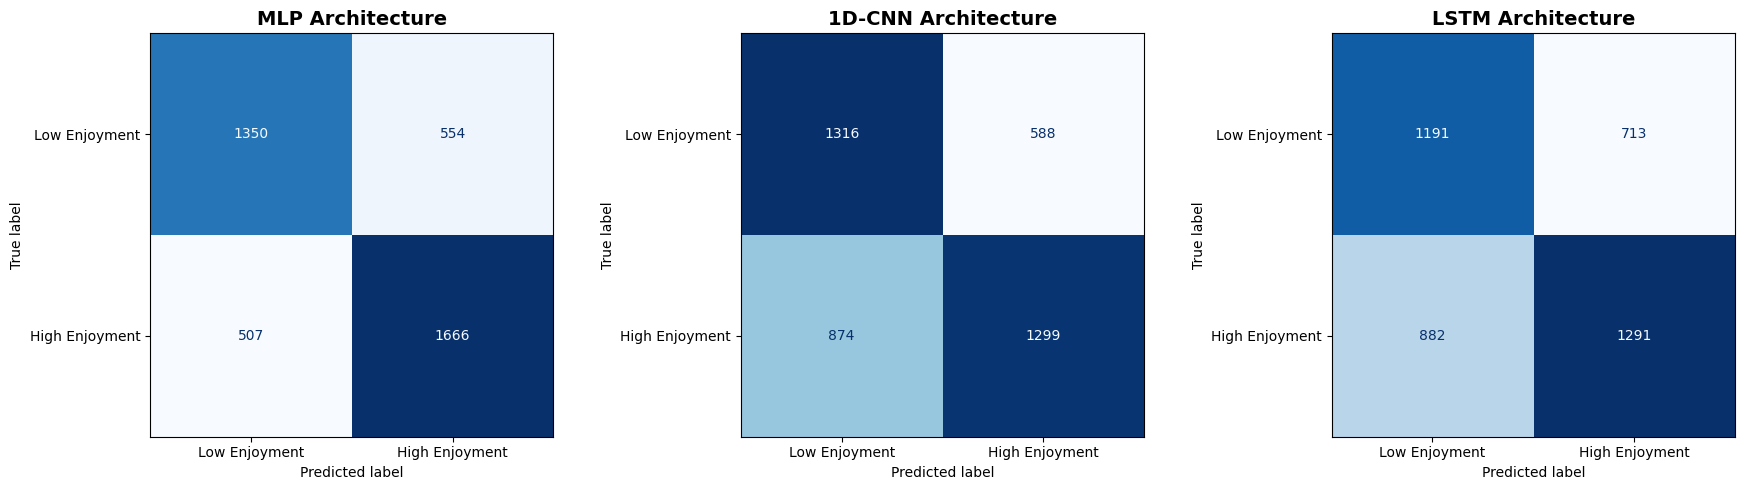

In [ ]:
print("Generating Confusion Matrices\n")

# create a 1x3 subplot grid for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['MLP', '1D-CNN', 'LSTM']

for ax, name in zip(axes, model_names):
    model = trained_dl_models[name]

    # dynamically select the correct test set dimension
    x_data = x_test_raw if name == 'MLP' else x_test_dl

    # predict and convert to binary labels
    y_prob = model.predict(x_data, verbose=0)
    y_pred = (y_prob > 0.5).astype(int).flatten()

    # generate and plot the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Low Enjoyment', 'High Enjoyment']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name} Architecture", fontsize=14, fontweight='bold')

plt.tight_layout()

fig_path = f'{project_dir}/DL_Confusion_Matrices.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Figure saved successfully to: {fig_path}")

plt.show()

### Model Serialization and Artifact Export

This final phase exports the trained deep learning architectures to the persistent storage directory. The models are saved using the modern .keras format, preserving both the architecture geometry and the trained weight parameters, allowing for seamless deployment or future inference without retraining.

In [ ]:
print("Serializing Deep Learning Models\n")

# loop through the trained models dictionary and save each one
for name, model in trained_dl_models.items():
    # replace hyphens with underscores for safe filenames (e.g., 1D-CNN -> 1D_CNN)
    safe_name = name.replace('-', '_')
    save_path = f'{model_save_dir}/{safe_name}.keras'

    model.save(save_path)
    print(f" Saved {name} -> {save_path}")

print("NOTEBOOK 03: DEEP LEARNING PIPELINE FULLY COMPLETED")
print(f"Final Models Dir : {model_save_dir}/")
print(f"Figures Saved    : {project_dir}/")
print("\nThe EEG Feature Extraction, Machine Learning, and Deep Learning pipelines are now entirely finished.")

Serializing Deep Learning Models

 Saved MLP -> /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models/MLP.keras
 Saved 1D-CNN -> /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models/1D_CNN.keras
 Saved LSTM -> /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models/LSTM.keras
NOTEBOOK 03: DEEP LEARNING PIPELINE FULLY COMPLETED
Final Models Dir : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/saved_models/
Figures Saved    : /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/

The EEG Feature Extraction, Machine Learning, and Deep Learning pipelines are now entirely finished.


### ROC Curve Analysis for Deep Learning Models

This section visualizes the Receiver Operating Characteristic (ROC) curves for the trained deep learning architectures (MLP, 1D-CNN, LSTM). By calculating the Area Under the Curve (AUC), we evaluate the models' discriminative capacity across all classification thresholds. The code dynamically handles the varying input dimension requirements (2D vs 3D) of the sequential and dense networks.

Generating ROC Curves for Deep Learning Models

ROC Curves successfully exported to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/DL_ROC_Curves.png

Updated Deep Learning Metrics Table (with AUC):


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,MLP,0.7398,0.7505,0.7667,0.7395,0.8237
1,1D-CNN,0.6414,0.6884,0.5978,0.6413,0.7049
2,LSTM,0.6088,0.6442,0.5941,0.6092,0.6453


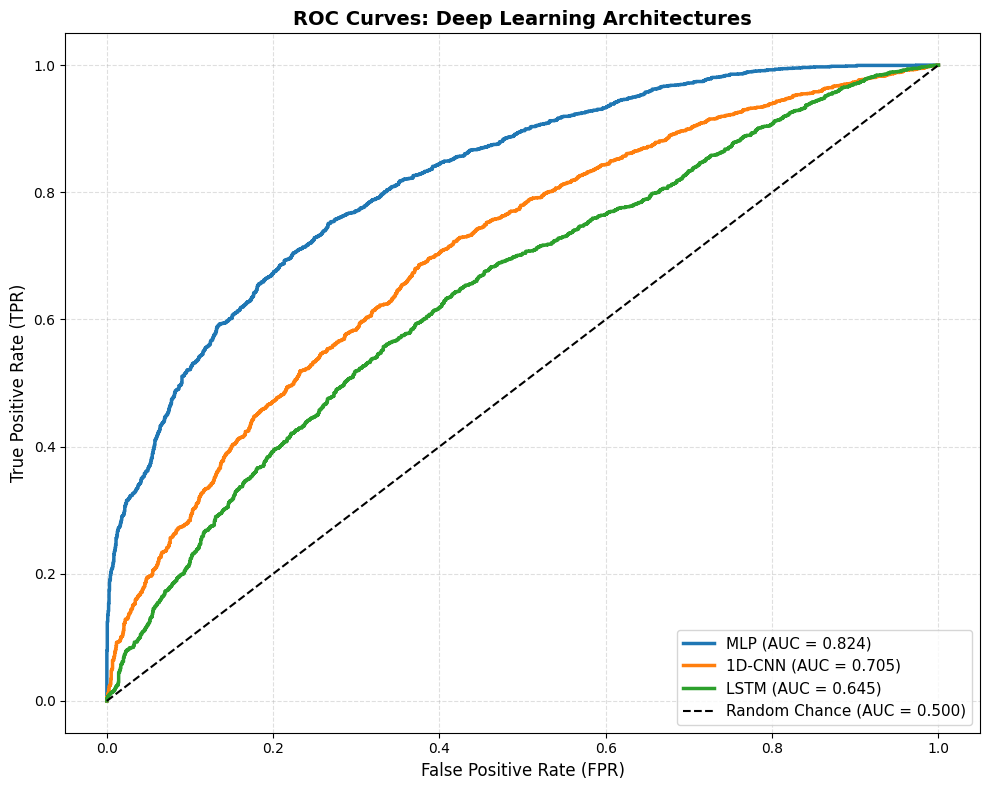

In [ ]:
print("Generating ROC Curves for Deep Learning Models\n")

from sklearn.metrics import roc_curve, auc

# create plot canvas
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
auc_dl_results = {}

# loop through the trained models to calculate and plot ROC
for (name, model), color in zip(trained_dl_models.items(), colors):

    # dynamically select the correct test set dimension
    x_data = x_test_raw if name == 'MLP' else x_test_dl

    # get raw prediction probabilities
    y_prob = model.predict(x_data, verbose=0).flatten()

    # calculate false positive rate, true positive rate, and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_dl_results[name] = round(roc_auc, 4)

    # plot individual model curves
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

# plot random chance baseline (diagonal line)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

# format the plot
ax.set_title('ROC Curves: Deep Learning Architectures', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.4, linestyle='--')

plt.tight_layout()

fig_path = f'{project_dir}/DL_ROC_Curves.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"ROC Curves successfully exported to: {fig_path}")

if 'df_dl_comparison' in locals():
    df_dl_comparison['AUC'] = df_dl_comparison['Model'].map(auc_dl_results)

    # re-sort by AUC to see the best overall performer at the top
    df_dl_comparison.sort_values(by='AUC', ascending=False, inplace=True)
    print("\nUpdated Deep Learning Metrics Table (with AUC):")

    # display the updated table with full gradient
    display(df_dl_comparison)


Generating Final ML vs DL Comparison Chart...


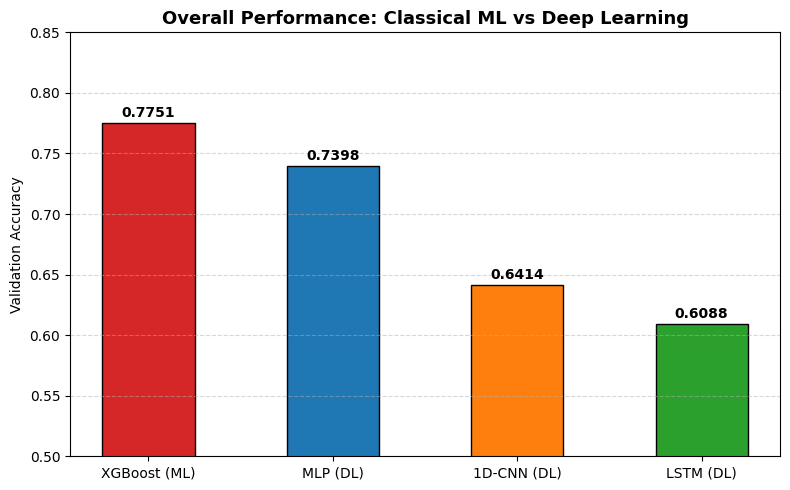

Final Comparison chart saved to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ML_vs_DL_Comparison.png


In [ ]:
### Final Comparison: Machine Learning vs Deep Learning

import matplotlib.pyplot as plt
import numpy as np

print("Generating Final ML vs DL Comparison Chart...")

# We know XGBoost scored ~0.7750 from Notebook 02, and we have DL results here.
# Let's extract MLP, CNN, and LSTM accuracies from the df_dl_comparison table
mlp_acc = df_dl_comparison.loc[df_dl_comparison['Model'] == 'MLP', 'Accuracy'].values[0]
cnn_acc = df_dl_comparison.loc[df_dl_comparison['Model'] == '1D-CNN', 'Accuracy'].values[0]
lstm_acc = df_dl_comparison.loc[df_dl_comparison['Model'] == 'LSTM', 'Accuracy'].values[0]
xgb_acc = 0.7751 # XGBoost Accuracy from Notebook 02

models = ['XGBoost (ML)', 'MLP (DL)', '1D-CNN (DL)', 'LSTM (DL)']
accuracies = [xgb_acc, mlp_acc, cnn_acc, lstm_acc]
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', width=0.5)

ax.set_ylim(0.50, 0.85)
ax.set_ylabel('Validation Accuracy')
ax.set_title('Overall Performance: Classical ML vs Deep Learning', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.4f}', ha='center', fontweight='bold')

plt.tight_layout()
fig_path = f'{project_dir}/ML_vs_DL_Comparison.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Comparison chart saved to: {fig_path}")